### ProbTNM simple: 

In [9]:
%load_ext autoreload
%autoreload 2

from typing import Optional, List, Dict

import jax
import numpy as np
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
import sklearn.gaussian_process.kernels as gp_kern

from source.features import PPFeature, RBFFeature
from source.models.LaplaceBTN import LaplaceBTN
from source.models.MeanFieldBTN import MeanFieldBTN
from source.models.StructPostBTN import StructPostBTN


PARAMS = {
    'figure.figsize': (10, 5),
    'figure.constrained_layout.use': True,
    'figure.facecolor': 'white',
    'font.size': 10,
    'axes.labelsize': 14,
    'legend.fontsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'axes.titlesize': 16,
    'figure.max_open_warning': 50,
}
sns.set_theme()

def plot_x3_results(
    data, 
    pred_mean, 
    pred_std,
    title: str, 
    figsize: tuple[int] = (5, 6),
    save_path: Optional[str] = None,
    show_plot: bool = True,
    y_limits: Optional[tuple] = None,
):
    with mpl.rc_context(PARAMS):
        x_train, x_test, y_train, y_test, y_test_true = data
        fig, ax = plt.subplots(figsize=figsize)
        ax.plot(x_test, pred_mean, color='red', linewidth=1, label=r'Predictive Mean $\mu$')
        ax.fill_between(
            x_test[:, 0], 
            (pred_mean - 3*pred_std),
            (pred_mean + 3*pred_std), 
            color='red', 
            alpha=.1, 
            label=r'$\mu \pm 3 \sigma$ '
        )
        ax.plot(x_test, y_test_true, color='blue', linewidth=1, label=r'True $\mathbb{E}[y]$')
        ax.scatter(x_test, y_test, marker='*', s=10, color='green', label='Test Data')
        ax.scatter(x_train, y_train, marker='o', s=10, color='blue', label='Train Data')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_title(title)
        if y_limits:
            ax.set_ylim(y_limits) 
        ax.grid(True)
        ax.legend();
        if save_path: 
            plt.savefig(save_path)
        if show_plot:
            plt.show()
        else:
            plt.close()

def generate_x3_data(n_samples, d_dim, min_v=-4, max_v=4, std_err=3, seed=None, sort_x=True):
    rs = np.random.RandomState(seed)
    x = rs.uniform(min_v, max_v, (n_samples, d_dim))
    if sort_x:
        x = np.sort(x, axis=0)
    e = rs.normal(0.0, std_err, (n_samples,))
    y_true = (x**3).sum(axis=1)
    y = y_true + e
    return x, y, y_true

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Side by side comparison:

In [10]:
def plot_x3_results_multiple(
    results,
    data, 
    figsize: Optional[tuple[int, int]] = None,
    save_path: Optional[str] = None,
    show_plot: bool = True,
    y_limits: Optional[tuple] = None,
):
    """
    Plots multiple subplots in a dynamic grid layout for better comparison of model predictions.

    Parameters:
        results: Dictionary where keys are model names and values contain:
                 - "pred_mean": Mean predictions
                 - "pred_std": Standard deviation of predictions
                 - "y_test": True y values (for reference)
                 - "x_test": Corresponding x values
        data: Tuple containing (x_train, x_test, y_train, y_test)
        figsize: Optional tuple defining figure size, auto-calculated if not provided
        save_path: Optional path to save the figure
        show_plot: Whether to display the plot
        y_limits: Optional y-axis limits
    """
    with mpl.rc_context(PARAMS):
        num_models = len(results)
        cols = int(np.ceil(np.sqrt(num_models)))  # Number of columns
        rows = int(np.ceil(num_models / cols))    # Number of rows
        if figsize is None:
            figsize = (cols * 5, rows * 4) # Adjust based on grid size
        fig, axes = plt.subplots(rows, cols, figsize=figsize, sharex=False, sharey=False)
        axes = np.ravel(axes) # Ensure axes is a 1D list for consistent iteration
        x_train, x_test, y_train, y_test, y_test_true = data
        legend_handles = []
        legend_labels = []
        for i, (model_name, model_results) in enumerate(results.items()):
            ax = axes[i]
            pred_mean = model_results["pred_mean"]
            pred_std = model_results["pred_std"]
            mean_line, = ax.plot(x_test, pred_mean, color='red', linewidth=1, label=r'Predictive Mean $\mu$')
            fill = ax.fill_between(
                x_test[:, 0], 
                (pred_mean - 3 * pred_std),
                (pred_mean + 3 * pred_std), 
                color='red', 
                alpha=0.1, 
                label=r'$\mu \pm 3 \sigma$'
            )
            mean_true, = ax.plot(x_test, y_test_true, color='blue', linewidth=1, label=r'True $\mathbb{E}[y]$')
            test_scatter = ax.scatter(x_test, y_test, marker='*', s=10, color='green', label='Test Data')
            train_scatter = ax.scatter(x_train, y_train, marker='o', s=10, color='blue', label='Train Data')
            ax.set_title(model_name)
            ax.grid(True)
            if y_limits: ax.set_ylim(y_limits)
            ax.set_xlabel('x')
            ax.set_ylabel('y')
            if i == 0:
                legend_handles.extend([mean_line, fill, mean_true, test_scatter, train_scatter])
                legend_labels.extend([r'Predictive Mean $\mu$', r'$\mu \pm 3 \sigma$', r'True $\mathbb{E}[y]$', 'Test Data', 'Train Data'])
        for j in range(num_models, len(axes)):
            fig.delaxes(axes[j])
        legend = fig.legend(
            handles=legend_handles, labels=legend_labels,
            loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0,
            frameon=False, #fontsize=10, markerscale=0.7, labelspacing=0.5
        )
        if save_path: 
            plt.savefig(save_path, bbox_inches="tight", bbox_extra_artists=[legend])
        if show_plot:
            plt.show()
        else:
            plt.close()


def train_and_evaluate_models(models: Dict[str, object], data):
    """
    Trains models, makes predictions, and stores results in a dictionary.

    Parameters:
        models: Dictionary where keys are model names and values are model instances.
        data: Tuple containing (x_train, x_test, y_train, y_test)

    Returns:
        results: Dictionary containing predictions and related metrics for each model.
    """
    x_train, x_test, y_train, y_test = data
    results = {}

    for model_name, model in models.items():
        print(f"Training model: {model_name}")
        model.fit(x_train, y_train)
        if  'GP' not in model_name:
            pred_mean = model.predict(x_test)
            pred_std = model.predict_std(x_test, std_mode='sampling')
        else:
            pred_mean, pred_std = model.predict(x_test, return_std=True)
        results[model_name] = {
            "pred_mean": pred_mean,
            "pred_std": pred_std,
        }
    return results

#### Generate the data:

In [5]:
n_samples, d_dim, std_err, seed = 20, 1, 3, 13
x_train, y_train, _ = generate_x3_data(n_samples, d_dim, std_err=std_err, seed=seed)
print('data:', x_train.shape, y_train.shape)

n_samples_test = 100
x_test, y_test, y_test_true = generate_x3_data(n_samples_test, d_dim, min_v=-5, max_v=5, std_err=std_err, seed=14)

# Shared hyperparameters
#beta_e, beta_w = None, None
beta_e, beta_w = 1 / std_err**2, 1 / 0.5**2
rank, fmap, m_order, n_epoch, n_loss_samples = 2, PPFeature(), 4, 1000, 5

data: (20, 1) (20,)


Training model: (Full) MF-BTN (Poly)
Training model: SP-BTN (Poly)
Training model: GP (White + Dot**3)


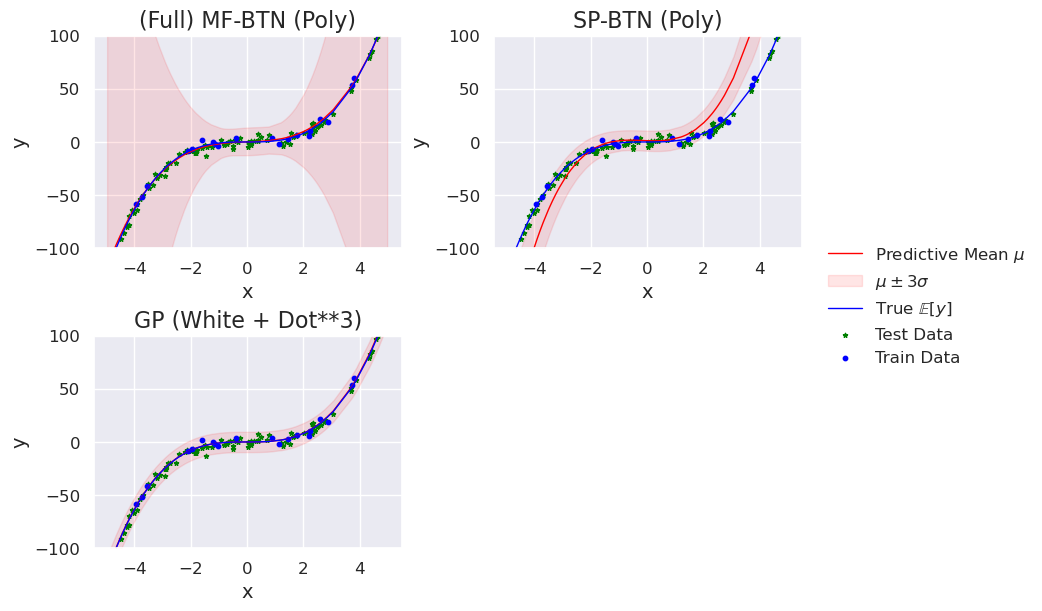

In [7]:
# Define models
models = {
    "(Full) MF-BTN (Poly)": MeanFieldBTN(
        rank, fmap, m_order, n_epoch, beta_e, beta_w, seed, 
        opt_params={'train_mode': 'GD', 'lr': 1e-6},
        n_loss_samples=n_loss_samples,
    ),
    "SP-BTN (Poly)": StructPostBTN(
        rank, fmap, m_order, n_epoch, beta_e, beta_w, seed, 
        opt_params={'train_mode': 'GD', 'lr': 1e-6}, 
        n_loss_samples=n_loss_samples,
        m_rank=10,
        n_epoch_global = 5,
        beta_e_n_samples = 5,
    ),
    "GP (White + Dot**3)": GaussianProcessRegressor(
        kernel=gp_kern.DotProduct()**3 + gp_kern.WhiteKernel(1),#/beta_e), 
        random_state=0
    ),
    #"LA-BTN (Poly)": LaplaceBTN(
    #    rank, fmap, m_order, n_epoch, beta_e, beta_w, seed,
    #    opt_params={'train_mode': 'ALS'}, 
    #    block_cov=False,
    #),
}
data = (x_train, x_test, y_train, y_test)
model2res = train_and_evaluate_models(models, data)

plot_x3_results_multiple(
    model2res, (*data, y_test_true), figsize=(8, 6), y_limits=(-100, 100)
)

In [ ]:
models['']

dict_keys(['(Full) MF-BTN (Poly)', 'SP-BTN (Poly)', 'GP (White + Dot**3)'])

Training model: LA-BTN (Poly, Full)
Training model: LA-BTN (Fourier, Full)
Training model: LA-BTN (Poly, Block)
Training model: LA-BTN (Fourier, Block)


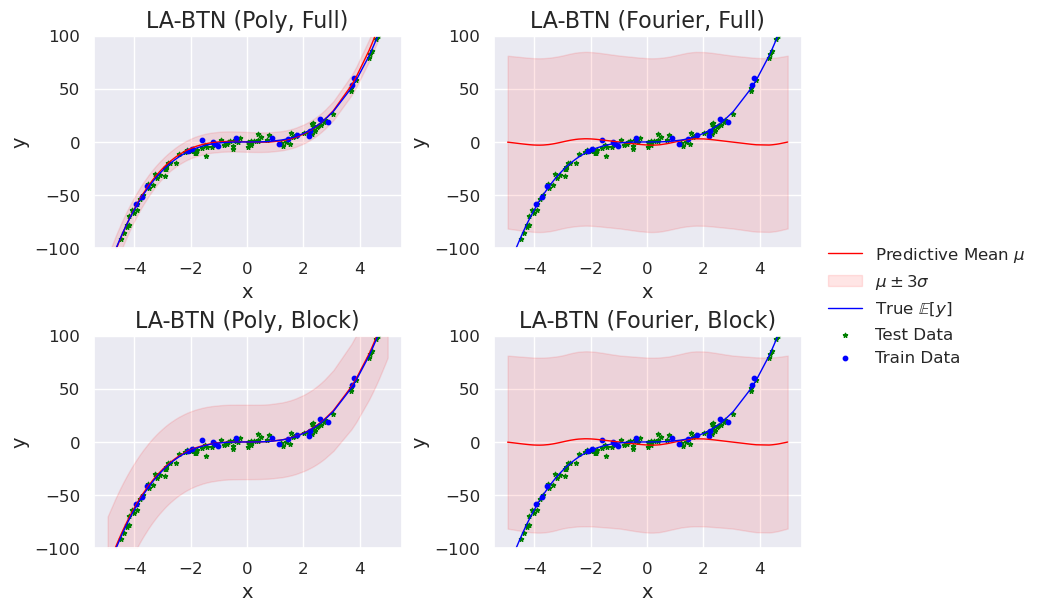

In [7]:
# Define models
models = {
    "LA-BTN (Poly, Full)": LaplaceBTN(
        rank, fmap, m_order, n_epoch, beta_e, beta_w, seed,
        opt_params={'train_mode': 'ALS'}, 
        block_cov=False,
    ),
    "LA-BTN (Fourier, Full)": LaplaceBTN(
        rank, RBFFeature(), m_order, n_epoch, beta_e, beta_w, seed,
        opt_params={'train_mode': 'ALS'}, 
        block_cov=False,
    ),
    "LA-BTN (Poly, Block)": LaplaceBTN(
        rank, fmap, m_order, n_epoch, beta_e, beta_w, seed,
        opt_params={'train_mode': 'ALS'}, 
        block_cov=True,
    ),
    "LA-BTN (Fourier, Block)": LaplaceBTN(
        rank, RBFFeature(), m_order, n_epoch, beta_e, beta_w, seed,
        opt_params={'train_mode': 'ALS'}, 
        block_cov=True,
    ),
}
data = (x_train, x_test, y_train, y_test)
model2res = train_and_evaluate_models(models, data)

plot_x3_results_multiple(
    model2res, (*data, y_test_true), figsize=(8, 6), y_limits=(-100, 100)
)

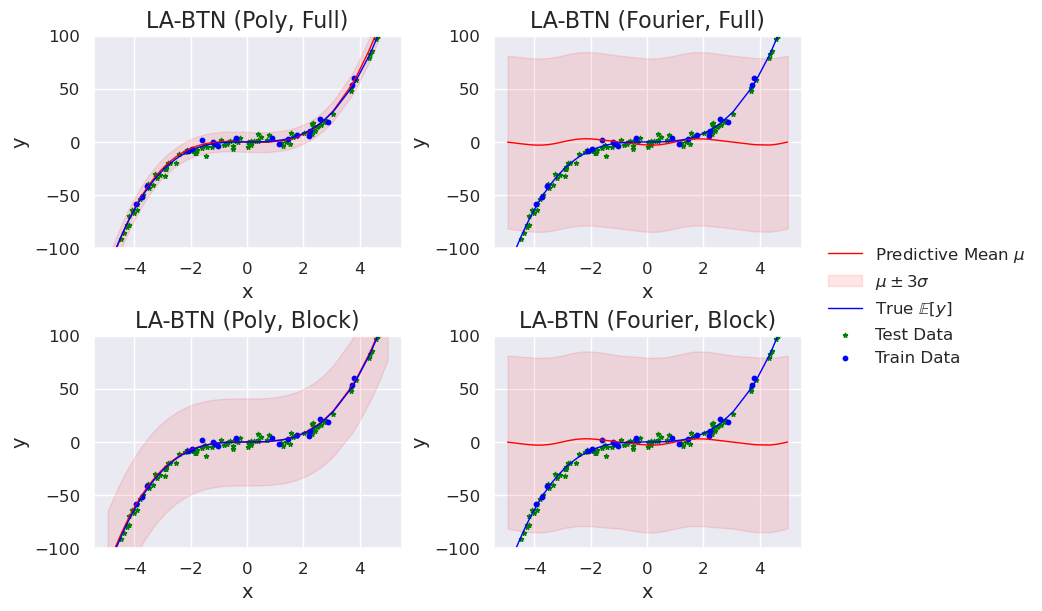

In [191]:
plot_x3_results_multiple(
    model2res, (*data, y_test_true), figsize=(8, 6), y_limits=(-100, 100), save_path='./artifacts/toy_cubic/toy_cubic_la.png'
)

### Generate some data:

In [6]:
n_samples, d_dim, std_err, seed = 20, 1, 3, 13
x_train, y_train, _ = generate_x3_data(n_samples, d_dim, std_err=std_err, seed=seed)
print('data:', x_train.shape, y_train.shape)

n_samples_test = 100
x_test, y_test, y_test_true = generate_x3_data(n_samples_test, d_dim, min_v=-5, max_v=5, std_err=std_err, seed=14)

# Shared hyperparameters
beta_e, beta_w = None, None
#beta_e, beta_w = 1 / std_err**2, 1 / 0.5**2
rank, fmap, m_order, n_epoch, n_loss_samples = 2, PPFeature(), 4, 1000, 5#10

data: (20, 1) (20,)


### MF-BTN (Updated 27.01.2025):

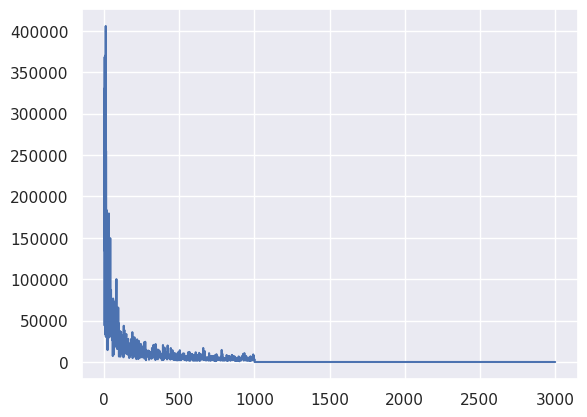

20.65837330404288 1.1623259104529153


In [6]:
mf_btn = MeanFieldBTN(
    rank, fmap, m_order, n_epoch, beta_e, beta_w, seed, 
    opt_params={'train_mode': 'GD', 'lr': 1e-6},
    n_loss_samples=n_loss_samples,
)
mf_btn.fit(x_train, y_train);
plt.plot(mf_btn.loss_list)
plt.show()
print(1 / np.sqrt(mf_btn.beta_e), 1 / np.sqrt(mf_btn.beta_w))

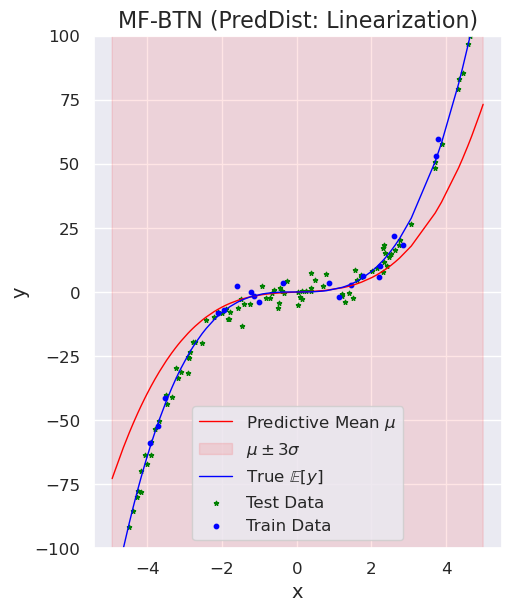

In [5]:
pred_mean = mf_btn.predict(x_test)
pred_std = mf_btn.predict_std(x_test, std_mode='linearize') 
plot_x3_results(
    [x_train, x_test, y_train, y_test, y_test_true],
    pred_mean, pred_std,
    title='MF-BTN (PredDist: Linearization)',
    y_limits=(-100, 100),
)

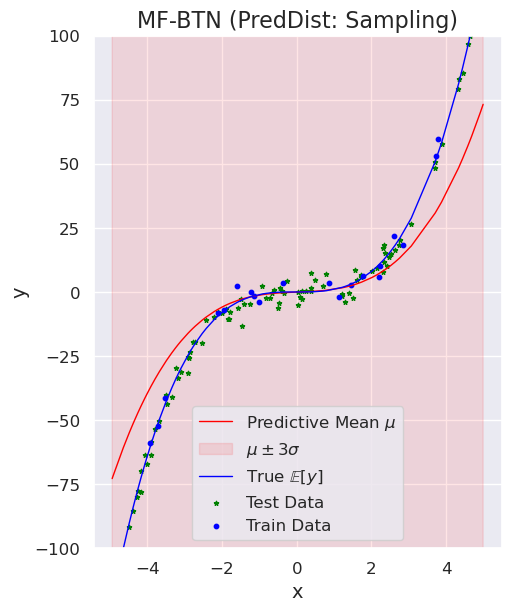

In [6]:
pred_mean = mf_btn.predict(x_test)
pred_std = mf_btn.predict_std(x_test, std_mode='sampling')
plot_x3_results(
    [x_train, x_test, y_train, y_test, y_test_true],
    pred_mean, pred_std,
    title='MF-BTN (PredDist: Sampling)',
    y_limits=(-100, 100),
)

### SP-BTN (Updated 28.01.2025):

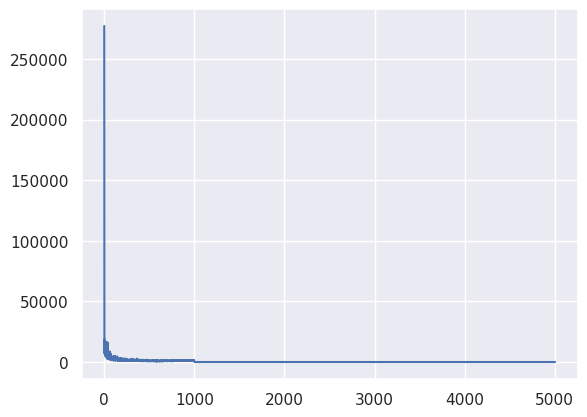

71.50979904591028 3.4324753944438084


In [7]:
m_rank = 10
sp_btn = StructPostBTN(
    rank, fmap, m_order, n_epoch, beta_e, beta_w, seed, 
    opt_params={'train_mode': 'GD', 'lr': 1e-6}, 
    n_loss_samples=n_loss_samples,
    m_rank=m_rank,
    n_epoch_global = 5,
    beta_e_n_samples = 5,
)
sp_btn.fit(x_train, y_train);
plt.plot(sp_btn.loss_list)
plt.show()
print(1 / np.sqrt(sp_btn.beta_e), 1 / np.sqrt(sp_btn.beta_w))

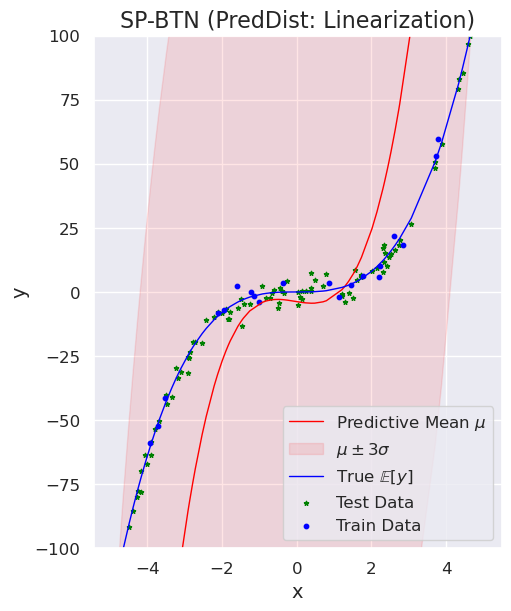

In [8]:
pred_mean = sp_btn.predict(x_test)
pred_std = sp_btn.predict_std(x_test, std_mode='linearize') 
plot_x3_results(
    [x_train, x_test, y_train, y_test, y_test_true],
    pred_mean, pred_std,
    title='SP-BTN (PredDist: Linearization)',
    y_limits=(-100, 100),
)

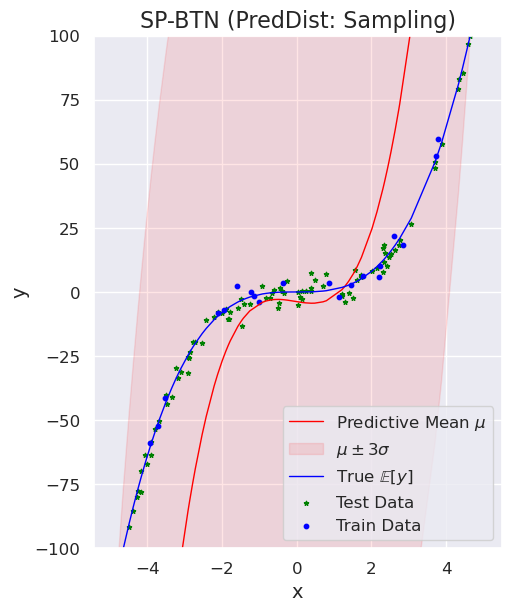

In [9]:
pred_mean = sp_btn.predict(x_test)
pred_std = sp_btn.predict_std(x_test, std_mode='sampling')
plot_x3_results(
    [x_train, x_test, y_train, y_test, y_test_true],
    pred_mean, pred_std,
    title='SP-BTN (PredDist: Sampling)',
    y_limits=(-100, 100),
)

### LA-BTN (Update 28.01.2025):

In [14]:
laplace_btn = LaplaceBTN(
    rank, fmap, m_order, n_epoch, beta_e, beta_w, 
    seed, opt_params={'train_mode': 'ALS'}, block_cov=False
)
laplace_btn.fit(x_train, y_train);
print(1 / np.sqrt(laplace_btn.beta_e), 1 / np.sqrt(laplace_btn.beta_w))

2.8062122627590877 0.8554995122970822


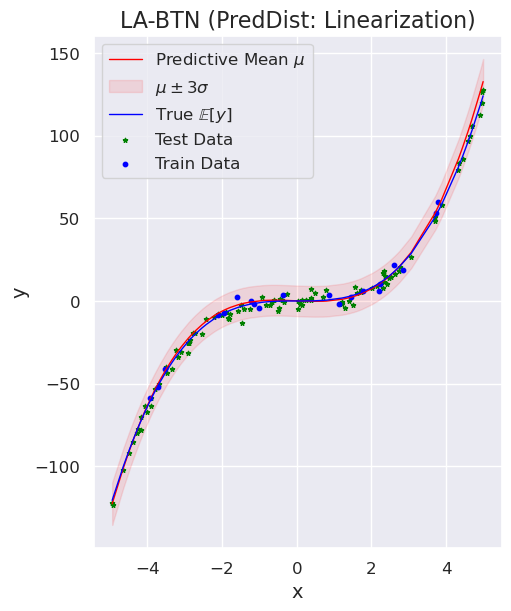

In [15]:
pred_mean = laplace_btn.predict(x_test)
pred_std = laplace_btn.predict_std(x_test, std_mode='linearize')
plot_x3_results(
    [x_train, x_test, y_train, y_test, y_test_true],
    pred_mean, pred_std,
    title='LA-BTN (PredDist: Linearization)'
)

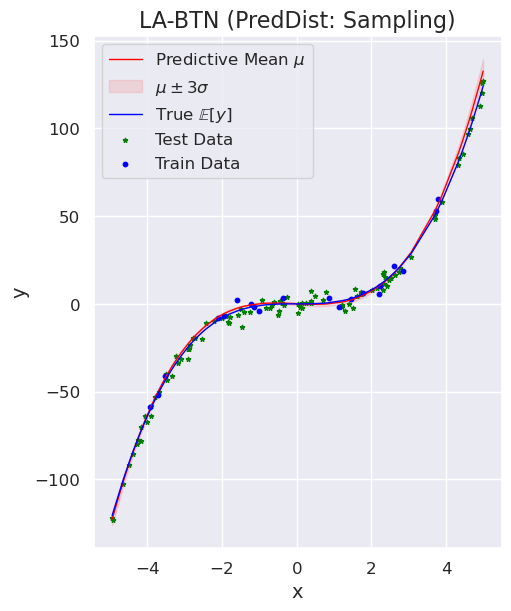

In [13]:
pred_mean = laplace_btn.predict(x_test)
pred_std = laplace_btn.predict_std(x_test, std_mode='sampling')
plot_x3_results(
    [x_train, x_test, y_train, y_test, y_test_true],
    pred_mean, pred_std,
    title='LA-BTN (PredDist: Sampling)'
)